# 🪜 Funnel Analyzer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/funnel-analyzer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/funnel-analyzer/demo.ipynb)

> **Pain point:** *We can't see where users drop off.*

A conversion funnel that nobody can compute is just a vibe. This takes a raw event log and an ordered list of steps, and tells you exactly how many users reach each step, where the **biggest leak** is, and how conversion differs by segment — so you know which step to fix first.

**What this notebook covers**
1. The core logic — strict ordered funnels
2. A sample event log (2,000 users, 5 steps)
3. The funnel + the biggest drop-off
4. A funnel chart you can drop into a deck
5. Conversion by segment (mobile vs desktop)

*(The Streamlit app renders this as an interactive Plotly funnel; here we use matplotlib so the chart shows on GitHub.)*

## Step 1 — Strict ordered funnels

A user only counts at step *k* if they also completed every earlier step. That keeps the numbers monotonically non-increasing and honest — no "more people checked out than added to cart" nonsense. Pure pandas, no API keys.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import seaborn as sns

from funnel import (
    DEFAULT_STEPS,
    compute_funnel,
    compute_funnel_by_segment,
    sample_events,
    steps_to_frame,
)

sns.set_theme(style='whitegrid')
print('Funnel steps:', DEFAULT_STEPS)

Funnel steps: ['visit', 'view_product', 'add_to_cart', 'checkout', 'purchase']


## Step 2 — A sample event log

`sample_events()` generates a deterministic e-commerce log (seed=42): 2,000 users flowing through visit → view_product → add_to_cart → checkout → purchase, with a deliberate leak at checkout and a mobile penalty.

In [2]:
events = sample_events()
print(f'{len(events)} events from {events.user_id.nunique()} users')
events.head()

4416 events from 2000 users


,user_id,event,device,ts
0,0,visit,desktop,2026-01-23 01:08:00
1,0,view_product,desktop,2026-02-28 12:33:00
2,1,visit,mobile,2026-01-18 11:01:00
3,1,view_product,mobile,2026-02-15 04:39:00
4,2,visit,desktop,2026-02-17 21:07:00


## Step 3 — Compute the funnel

One call returns each step's user count, conversion vs the top and vs the previous step, and the single biggest drop-off.

In [3]:
res = compute_funnel(events, DEFAULT_STEPS)
print(f'Overall conversion: {res.overall_conversion}%')
print(f'Biggest leak: {res.biggest_drop} (-{res.biggest_drop_pct}%)')
steps_to_frame(res)

Overall conversion: 9.8%
Biggest leak: checkout (-62.9%)


,step,users,% of top,step conversion %,dropped,drop-off %
0,visit,2000,100.0,100.0,0,0.0
1,view_product,1244,62.2,62.2,756,37.8
2,add_to_cart,712,35.6,57.2,532,42.8
3,checkout,264,13.2,37.1,448,62.9
4,purchase,196,9.8,74.2,68,25.8


## Step 4 — The funnel chart

Bars sized by users at each step, with the biggest-leak step highlighted in red.

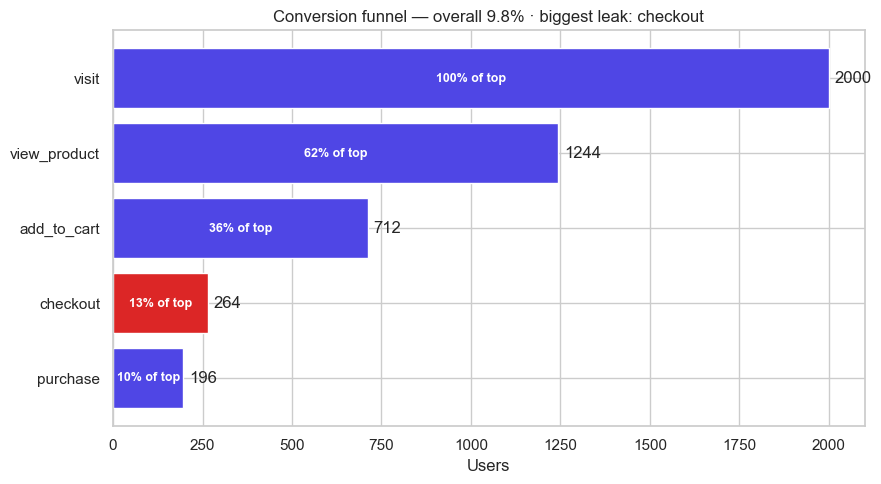

In [4]:
labels = [s.step for s in res.steps]
values = [s.users for s in res.steps]
colors = ['#DC2626' if s.step == res.biggest_drop else '#4F46E5' for s in res.steps]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1])
ax.bar_label(bars, fmt='%d', padding=4)
for s, bar in zip(res.steps[::-1], bars):
    ax.text(bar.get_width() * 0.5, bar.get_y() + bar.get_height()/2,
            f'{s.pct_of_top:.0f}% of top', va='center', ha='center',
            color='white', fontweight='bold', fontsize=9)
ax.set_xlabel('Users')
ax.set_title(f'Conversion funnel — overall {res.overall_conversion}% '
             f'· biggest leak: {res.biggest_drop}')
plt.tight_layout()
plt.savefig('funnel.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Conversion by segment

The same funnel split by device. If one segment converts far worse, that's a targeted fix — not a site-wide guess.

Overall conversion by device: {'desktop': 12.2, 'mobile': 8.2}


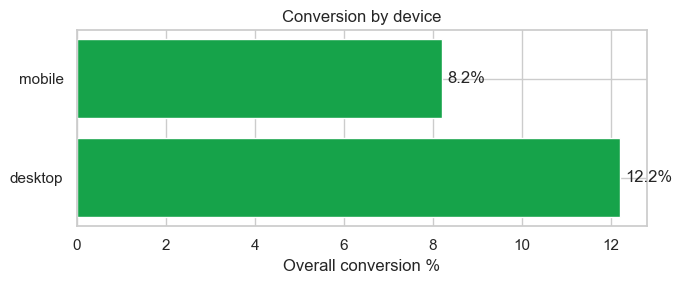

In [5]:
seg = compute_funnel_by_segment(events, DEFAULT_STEPS, 'device')
print('Overall conversion by device:', seg.by_segment)

fig, ax = plt.subplots(figsize=(7, 3))
names = list(seg.by_segment.keys())
vals = list(seg.by_segment.values())
bars = ax.barh(names, vals, color='#16A34A')
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlabel('Overall conversion %')
ax.set_title('Conversion by device')
plt.tight_layout()
plt.show()

## Summary

The sample funnel converts ~10% end-to-end, and the analyzer pins the worst leak at **checkout** — exactly where the data was rigged to bleed. The segment split shows **mobile** converting noticeably worse than desktop, pointing at a mobile checkout problem. That's the difference between "we're losing users" and "we're losing mobile users at checkout — fix that page."

## 🔧 Try your own

Uncomment and point it at your own event log:

In [6]:
# import pandas as pd
# my_events = pd.read_csv('your_events.csv')   # needs user + event columns
# my_steps = ['signup', 'activate', 'subscribe']
# res = compute_funnel(my_events, my_steps, user_col='user_id', event_col='event')
# print('Biggest leak:', res.biggest_drop)
# steps_to_frame(res)

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — Day 29 of the 60-day FDE portfolio.

**Run the Streamlit version** (interactive Plotly funnel):
```bash
pip install -r requirements.txt
streamlit run app.py
```